<a href="https://colab.research.google.com/github/JavierCarrillo12/Computacion-visual-jtorresle-jugomezra-dagarzonmo-jacarrillo/blob/main/Talleres/2025-07-04_taller_clasificacion_asistida_clip/Modelo_clasificacion_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q
!pip install matplotlib pillow numpy requests imageio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


¿Montar Google Drive? (s/n): n
Ruta absoluta a tu carpeta de imágenes (ej: /content/mi_carpeta): /content/2025-06-28_taller_clip_clasificacion_visual_verbal/images

→ Leyendo /content/2025-06-28_taller_clip_clasificacion_visual_verbal/images
  Contenido: ['woman_glass.jpg', 'cellphone.jpg', '.ipynb_checkpoints', 'woman.jpg', 'shoes.jpg', 'man.jpg'] 

Escribe tus descripciones separadas por comas (ej: celular, mueble, lámpara): hombre, mujer, mujer con gafas, zapatillas, celular


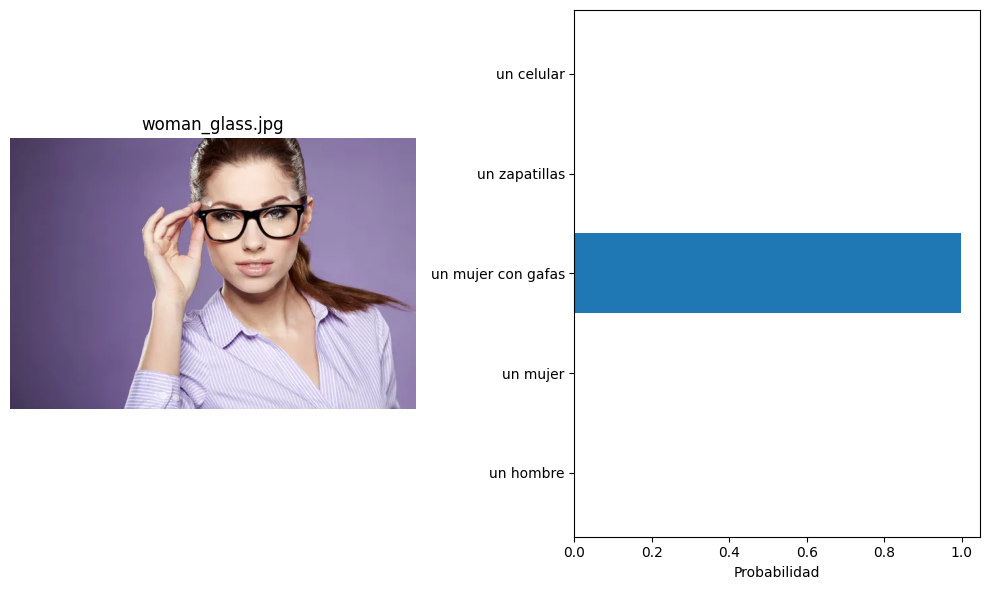

>>> woman_glass.jpg → un mujer con gafas (99.79%)
----------------------------------------


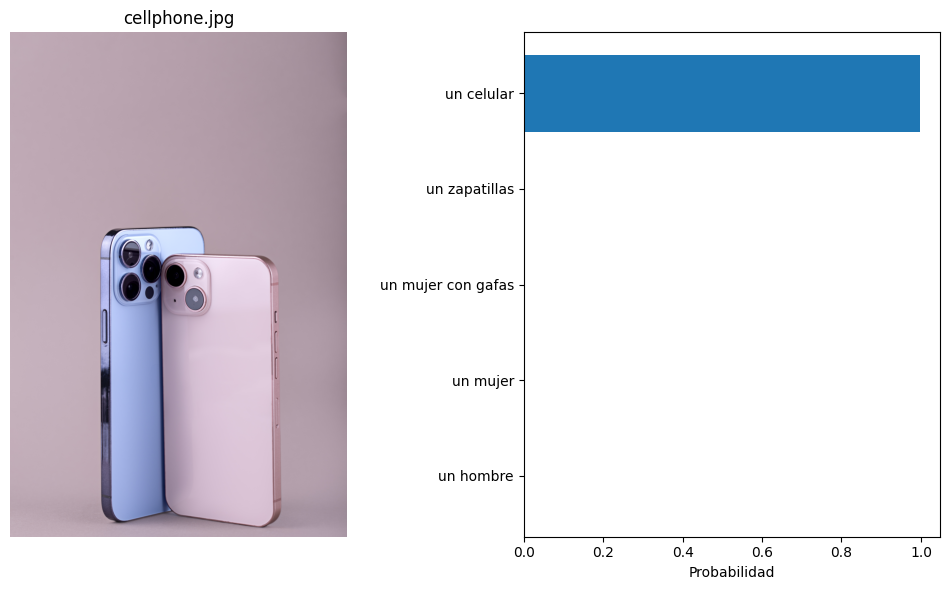

>>> cellphone.jpg → un celular (99.83%)
----------------------------------------


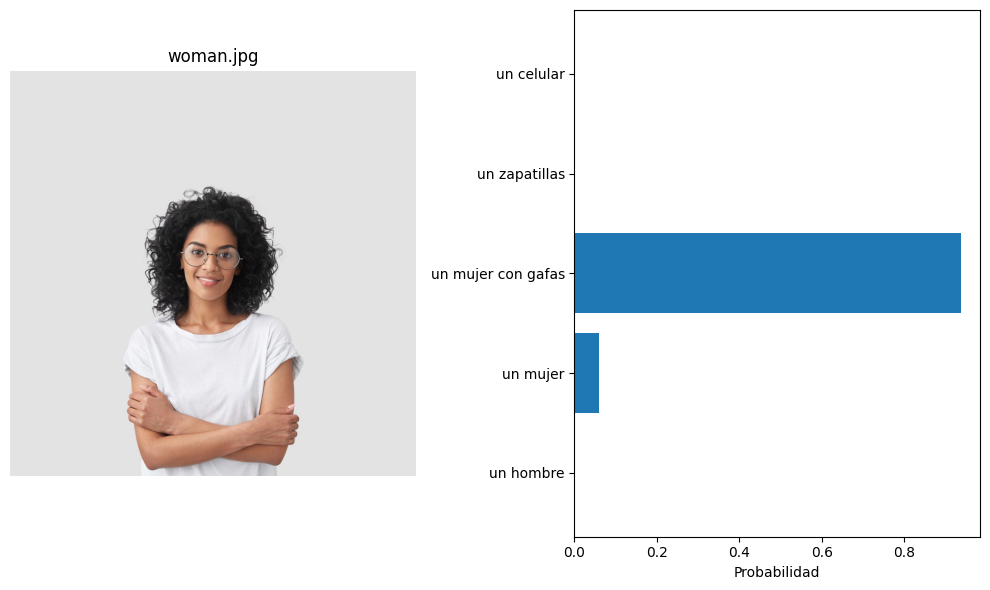

>>> woman.jpg → un mujer con gafas (93.72%)
----------------------------------------


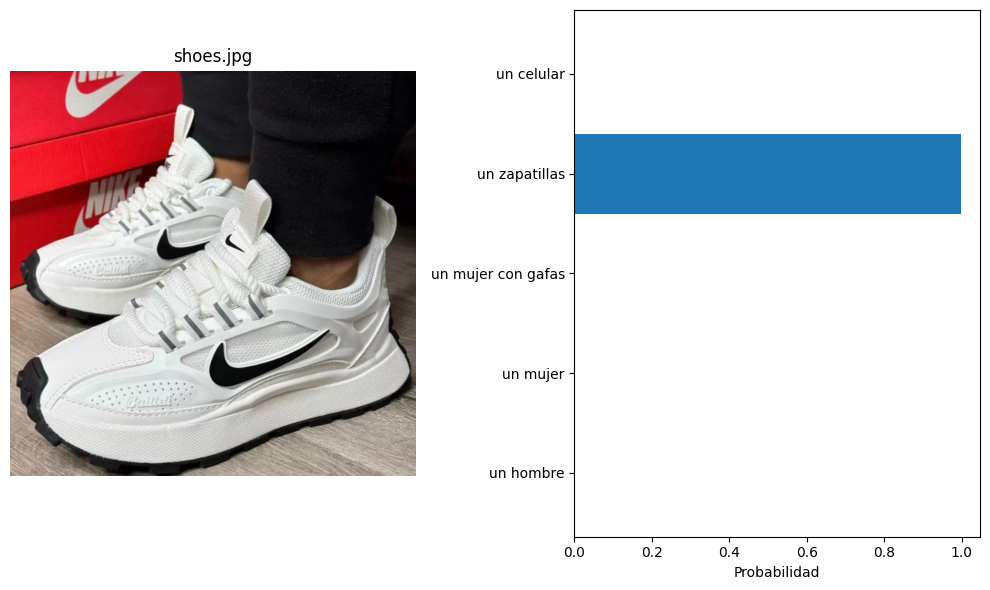

>>> shoes.jpg → un zapatillas (99.70%)
----------------------------------------


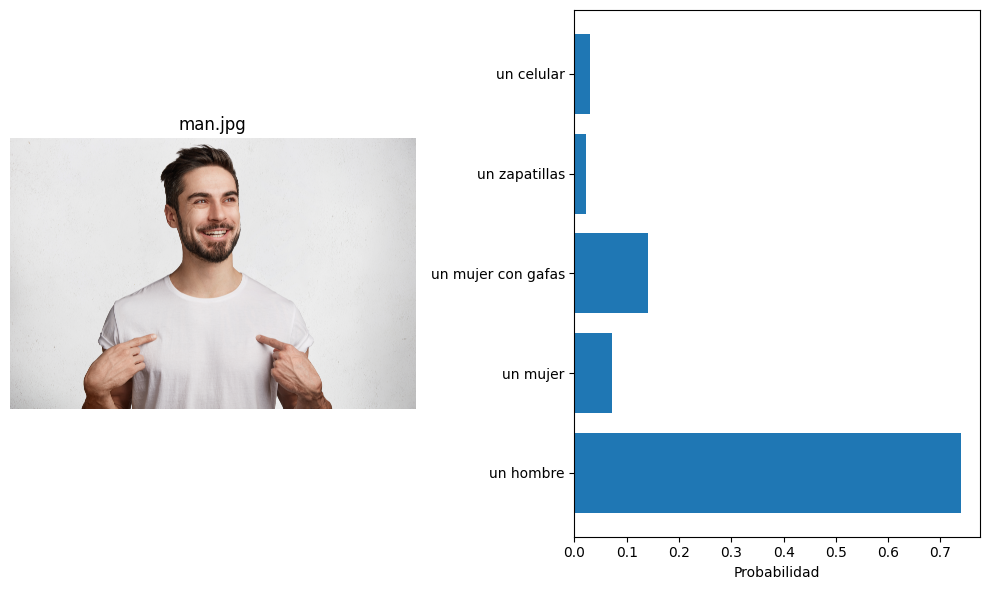

>>> man.jpg → un hombre (73.88%)
----------------------------------------


/tmp/ipython-input-17-1926042049.py:86: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))



GIF guardado en: /content/2025-06-28_taller_clip_clasificacion_visual_verbal/resultados/resultados.gif


In [17]:
# Importar librerías
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import imageio
from google.colab import drive

%matplotlib inline

# === (Opcional) Montar Drive ===
if input("¿Montar Google Drive? (s/n): ").lower() == 's':
    drive.mount('/content/drive')

# --- Pido al usuario la ruta donde están las imágenes ---
image_dir = input(
    "Ruta absoluta a tu carpeta de imágenes (ej: /content/mi_carpeta): "
).strip()

# Muestro contenido para que confirmes que ahí están tus JPG/PNG
print(f"\n→ Leyendo {image_dir}")
print("  Contenido:", os.listdir(image_dir), "\n")

# Carpeta dónde se guardarán resultados
output_dir = os.path.join(os.path.dirname(image_dir), 'resultados')
os.makedirs(output_dir, exist_ok=True)

# Dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"

# Cargo CLIP
model, preprocess = clip.load("ViT-B/32", device=device)


def load_images(image_dir):
    image_paths = [
        os.path.join(image_dir, fn)
        for fn in os.listdir(image_dir)
        if fn.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    if not image_paths:
        raise ValueError(f"No encontré imágenes en: {image_dir}")
    tensors = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        tensors.append(preprocess(img).unsqueeze(0).to(device))
    return image_paths, torch.cat(tensors, dim=0)


def classify_images(image_paths, images, text_descriptions):
    text_tokens = clip.tokenize(text_descriptions).to(device)
    with torch.no_grad():
        logits_per_image, _ = model(images, text_tokens)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    return probs


def visualize_results(image_paths, probs, text_descriptions, output_dir):
    result_images = []
    for img_path, prob in zip(image_paths, probs):
        plt.figure(figsize=(10, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(os.path.basename(img_path))

        plt.subplot(1, 2, 2)
        plt.barh(text_descriptions, prob)
        plt.xlabel('Probabilidad')
        plt.tight_layout()

        out_path = os.path.join(output_dir, f"res_{os.path.basename(img_path)}.png")
        plt.savefig(out_path)
        result_images.append(out_path)
        plt.show()

        top = text_descriptions[np.argmax(prob)]
        print(f">>> {os.path.basename(img_path)} → {top} ({np.max(prob):.2%})")
        print("-"*40)

    gif_path = os.path.join(output_dir, "resultados.gif")
    with imageio.get_writer(gif_path, mode='I', duration=1) as writer:
        for frame in result_images:
            writer.append_data(imageio.imread(frame))
    print(f"\nGIF guardado en: {gif_path}")


def main():
    # Cargo imágenes de la ruta que has puesto
    image_paths, images = load_images(image_dir)

    # Pido las descripciones dinámicamente
    descs = input(
        "Escribe tus descripciones separadas por comas (ej: celular, mueble, lámpara): "
    )
    text_descriptions = ["un " + d.strip() for d in descs.split(",")]

    probs = classify_images(image_paths, images, text_descriptions)
    visualize_results(image_paths, probs, text_descriptions, output_dir)


if __name__ == "__main__":
    main()


¿Montar Google Drive? (s/n): n
Ruta absoluta a tu carpeta de imágenes (ej: /content/mi_carpeta): /content/2025-06-28_taller_clip_clasificacion_visual_verbal/images

→ Leyendo /content/2025-06-28_taller_clip_clasificacion_visual_verbal/images
  Contenido: ['woman_glass.jpg', 'cellphone.jpg', '.ipynb_checkpoints', 'woman.jpg', 'shoes.jpg', 'man.jpg'] 

Escribe tus descripciones separadas por comas (ej: celular, mueble, lámpara): celular, mujer con gafas, hombre feliz, zapatillas


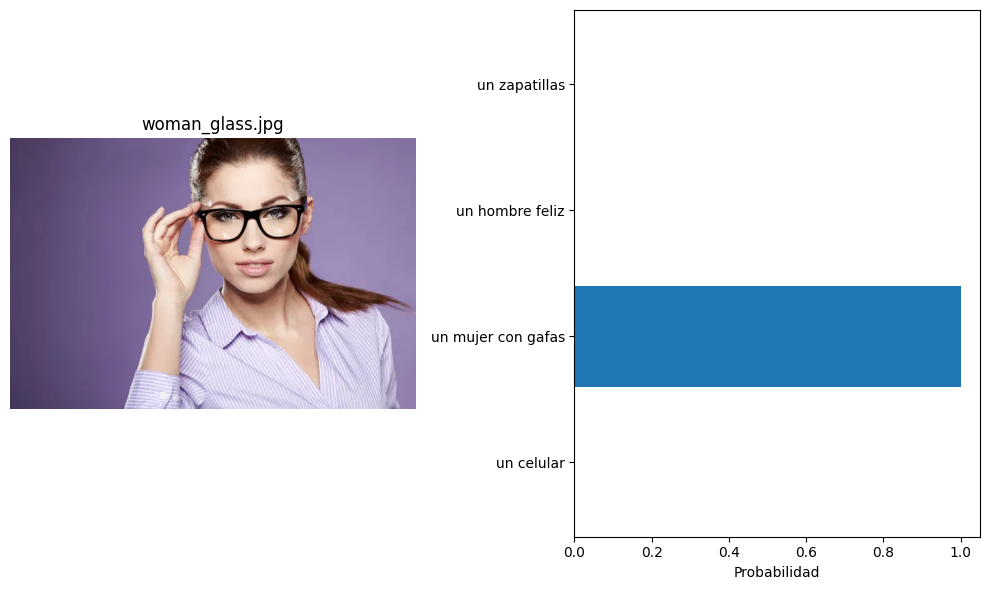

>>> woman_glass.jpg → un mujer con gafas (99.99%)
----------------------------------------


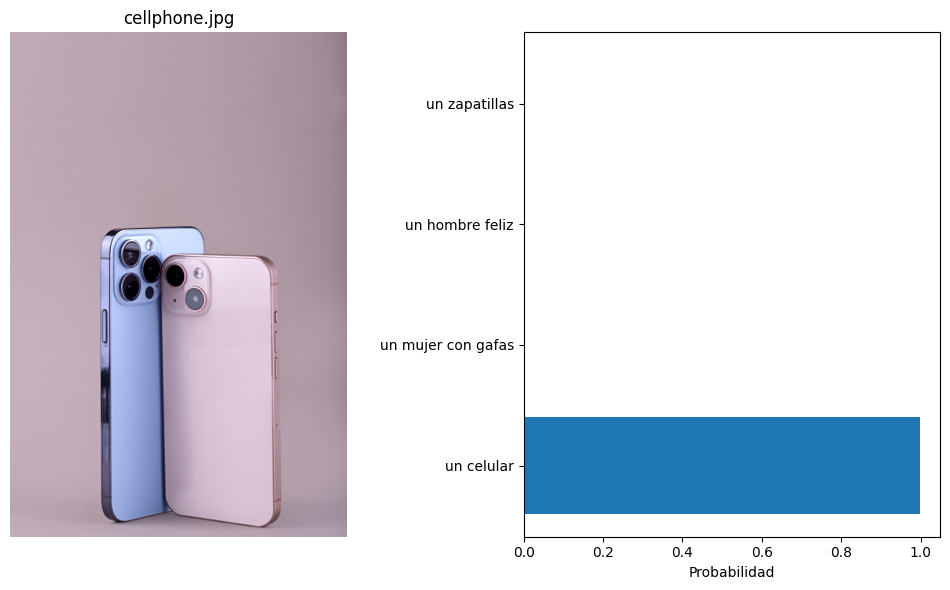

>>> cellphone.jpg → un celular (99.92%)
----------------------------------------


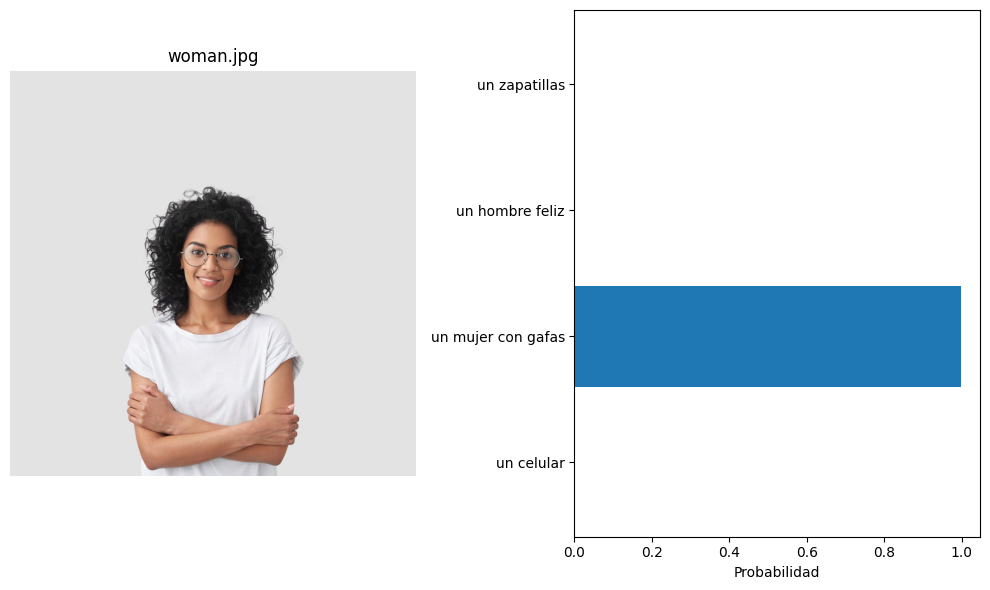

>>> woman.jpg → un mujer con gafas (99.79%)
----------------------------------------


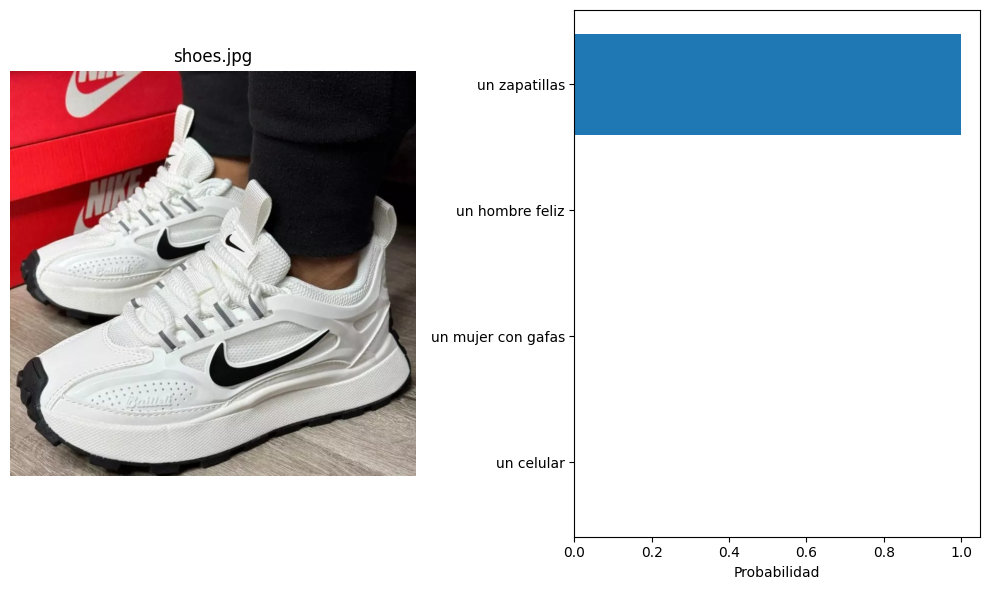

>>> shoes.jpg → un zapatillas (99.90%)
----------------------------------------


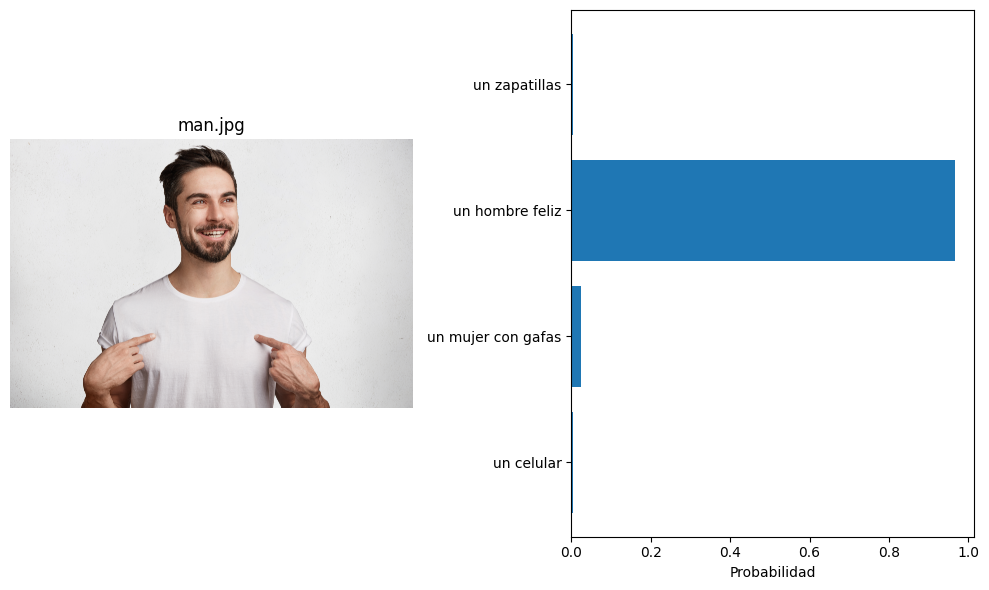

>>> man.jpg → un hombre feliz (96.58%)
----------------------------------------


/tmp/ipython-input-20-678804349.py:109: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))



[+] GIF final creado en: /content/2025-06-28_taller_clip_clasificacion_visual_verbal/resultados/resultados.gif


In [20]:
# Importar librerías
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import imageio
from google.colab import drive

# Habilitar inline plotting en Colab
%matplotlib inline

# === (Opcional) Montar Google Drive ===
if input("¿Montar Google Drive? (s/n): ").lower() == 's':
    drive.mount('/content/drive')

# --- Pedir la ruta donde están las imágenes ---
image_dir = input(
    "Ruta absoluta a tu carpeta de imágenes (ej: /content/mi_carpeta): "
).strip()

# Mostrar contenido para confirmación
print(f"\n→ Leyendo {image_dir}")
print("  Contenido:", os.listdir(image_dir), "\n")

# Directorio de salida (se crea junto a la carpeta de imágenes)
output_dir = os.path.join(os.path.dirname(image_dir), 'resultados')
os.makedirs(output_dir, exist_ok=True)

# Selección de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carga del modelo CLIP y su preprocesador
model, preprocess = clip.load("ViT-B/32", device=device)


def load_images(image_dir):
    """
    Carga todas las imágenes .jpg/.png del directorio y devuelve:
      - image_paths: lista de rutas a los archivos
      - images: tensor concatenado para pasar a CLIP
    """
    image_paths = [
        os.path.join(image_dir, fn)
        for fn in os.listdir(image_dir)
        if fn.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    if not image_paths:
        raise ValueError(f"No encontré imágenes en: {image_dir}")
    tensors = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        tensors.append(preprocess(img).unsqueeze(0).to(device))
    images = torch.cat(tensors, dim=0)
    return image_paths, images


def classify_images(image_paths, images, text_descriptions):
    """
    Dado un lote de imágenes y una lista de descripciones, devuelve
    una matriz de probabilidades (n_imágenes x n_descripciones).
    """
    text_tokens = clip.tokenize(text_descriptions).to(device)
    with torch.no_grad():
        logits_per_image, _ = model(images, text_tokens)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    return probs


def visualize_results(image_paths, probs, text_descriptions, output_dir):
    """
    Para cada imagen:
      1. Muestra la imagen y la gráfica de barras de probabilidades.
      2. Guarda la figura en output_dir.
    Al final, genera un GIF con todas las figuras guardadas.
    """
    result_images = []
    for img_path, prob in zip(image_paths, probs):
        plt.figure(figsize=(10, 6))

        # Mostrar la imagen original
        plt.subplot(1, 2, 1)
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(os.path.basename(img_path))

        # Mostrar la barra de probabilidades
        plt.subplot(1, 2, 2)
        plt.barh(text_descriptions, prob)
        plt.xlabel('Probabilidad')
        plt.tight_layout()

        # Guardar la figura
        out_path = os.path.join(output_dir, f"res_{os.path.basename(img_path)}.png")
        plt.savefig(out_path)
        result_images.append(out_path)
        plt.show()

        # Imprimir la etiqueta más probable
        top_idx = np.argmax(prob)
        print(f">>> {os.path.basename(img_path)} → {text_descriptions[top_idx]} ({prob[top_idx]:.2%})")
        print("-" * 40)

    # Crear y guardar el GIF con todas las figuras
    gif_path = os.path.join(output_dir, "resultados.gif")
    with imageio.get_writer(gif_path, mode='I', duration=1) as writer:
        for frame_path in result_images:
            writer.append_data(imageio.imread(frame_path))
    print(f"\n[+] GIF final creado en: {gif_path}")


def main():
    # 1) Carga las imágenes de la carpeta indicada
    image_paths, images = load_images(image_dir)

    # 2) Pide al usuario las descripciones
    descs = input(
        "Escribe tus descripciones separadas por comas (ej: celular, mueble, lámpara): "
    )
    text_descriptions = ["un " + d.strip() for d in descs.split(",")]

    # 3) Clasifica
    probs = classify_images(image_paths, images, text_descriptions)

    # 4) Visualiza, guarda y crea el GIF
    visualize_results(image_paths, probs, text_descriptions, output_dir)


if __name__ == "__main__":
    main()
